# Анализ результатов A/B-тестирования, проведенного интернет-магазином для провекри эффективности нового интерфейса в приложении

## Цели и задачи проекта

**Цель проекта**: оценить корректность и соответствие техническому заданию А/B-теста, который был проведен, чтобы выяснить увеличивает ли новый интерфейс онлайн магазина уровень конвесрсии пользователей в покупателей. Проанализировать результаты А/В-теста.

**Задачи**:
1. Оценка корректности проведения А/В теста.
2. Анализ результатов А/В теста.
3. Составления аналитической записки.

## Описание данных

Для анализа предоставлены данные о проведенных А/В тестированиях, включающие данные о пользователях, названиях А/В тестов и аднных об устройствах
- `ab_test_participants.csv` содержит данные о проведенных А/В тестах;
- `ab_test_events.zip` содержит данные о действиях пользоватенлей (событиях);

### Описание датасета `ab_test_participants`

- `user_id` — идентификатор пользователя;
- `group` — группа тестирования;
- `ab_test` — название А/В теста;
- `device` — вид устройства.

### Описание датасета `ab_test_events`

- `user_id` — идентификатор пользователя;
- `event_dt` — дата события;
- `event_name` — наименование события;
- `details` — детали события (стоимость привлечения клиента, стоимость покупки, комментарии).


## Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Оценка корректности проведения А/В-теста
3. Оценка результатов A/B-теста
4. Аналитическая записка

## 1. Загрузка данных и знакомство с ними


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [2]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [3]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [4]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


В датасете `participants` пропуски отсуствуют

In [5]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


В датасете `events` есть пропуски в столбце `details`, где содежится информация о стоимости привлечения клиента и стоимости покупки. Эти данные в дальнейшем анализе не требуются, т.к. на уровень конверсии не влияют. Оставляем пропуски без изменения.

In [6]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [7]:
events['event_name'].unique()

array(['End of Black Friday Ads Campaign', 'registration', 'product_page',
       'login', 'product_cart', 'purchase',
       'Start of Christmas&New Year Promo',
       'Start of CIS New Year Gift Lottery'], dtype=object)

In [8]:
# считаем количество событий "покупка" и "регистрация",где user_id = GLOBAL
global_count = events['event_name'].loc[(events['user_id']=='GLOBAL') & ((events['event_name']=='registration') | (events['event_name']=='purchase'))].count()
print(global_count)

15520


In [9]:
#считаем общее количество событий "покупка" и "регистрация"
total_count = events['event_name'].loc[(events['event_name']=='registration') | (events['event_name']=='purchase')].count()
print(total_count) 

249019


In [10]:
#считаем процент событий "покупка" и "рекгистрация" для user_id со значением GLOBAL
round(global_count*1.0/total_count*100,2)

6.23

Значение GLOBAL не имеет привязки к конкретному пользователю, поэтому не может быть использовано для расчета конверсии. Мы посчитали долю интересующих нас событий (регистрация и покупка) для  user_id =  GLOBAL - 6,23%. Принято решение удалить данные, где user_id	=  'GLOBAL'.	

In [11]:
# удаляем строки с  GLOBAL
events = events[events['user_id'] != 'GLOBAL']

## 2. Оценка корректности проведения А/В теста

 ### 2.1 Выделим пользователей, участвующих в тесте, и проверим:
   - равномерность распределения пользователей по группам теста,
   - отсутствие пересечений с конкурирующим тестом.

In [12]:
# выделим пользователей, учавствующих в тесте нового интерфейса
participants_exp = participants.loc[participants['ab_test']== 'interface_eu_test']

In [13]:
#расчет количества пользователей в каждой группе
group_a_count = participants_exp[participants_exp['group'] == 'A']['user_id'].nunique()
group_b_count = participants_exp[participants_exp['group'] == 'B']['user_id'].nunique()
print(f'Количесвто пользователей в группе А - {group_a_count}, количество пользователей в группе B - {group_b_count}')

Количесвто пользователей в группе А - 5383, количество пользователей в группе B - 5467


In [14]:
#расчет процентной разницы количества пользователей между группамми.
round(100*(group_a_count-group_b_count)/group_a_count,2)

-1.56

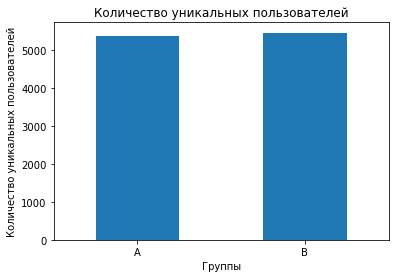

In [15]:
#строим график распределения пользователей по группам
unique_participants = participants_exp.groupby('group')['user_id'].nunique()
unique_participants.plot(kind = 'bar')
plt.title('Количество уникальных пользователей')
plt.xlabel('Группы')
plt.ylabel('Количество уникальных пользователей')
plt.xticks(rotation=0)
plt.show()

Участники по группам распределены равномерно.

In [16]:
#проверяем распределение по устройствам в каждой группе
device_per_a = participants_exp.loc[participants_exp['group'] == 'A'].groupby('device')['user_id'].nunique()
device_per_b = participants_exp.loc[participants_exp['group'] == 'B'].groupby('device')['user_id'].nunique()

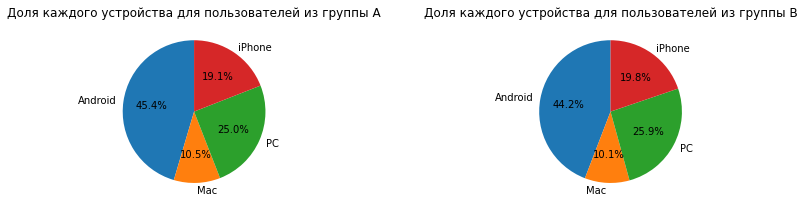

In [17]:
# строим график для сравнения распределения по группам
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3))

device_per_a.plot.pie(
    autopct='%1.1f%%', 
    startangle=90,      
    ax=ax1
)
ax1.set_title('Доля каждого устройства для пользователей из группы A')
ax1.set_ylabel('')

device_per_b.plot.pie(
    autopct='%1.1f%%', 
    startangle=90,      
    ax=ax2
)
ax2.set_title('Доля каждого устройства для пользователей из группы B')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

Распеределение по устройставм между группами равномерное

In [18]:
#ищем пересечения по пользователям с конкурирующим тестом 
recommender_system_test_users = participants[participants['ab_test'] == 'recommender_system_test']['user_id']
interface_eu_test_users = participants[participants['ab_test'] == 'interface_eu_test']['user_id']
intersection = list(set(recommender_system_test_users) & set(interface_eu_test_users))
print(intersection)

['D82DD23742E57665', 'C7750723906C925A', '14AEC962812EB706', '98720595D29108E9', '502902B3C32C72FF', '686549722B54A3E1', '902F92052587344F', 'C79239C16E4E6694', 'C615792E479BC0C8', '00EFA157F7B6E1C4', '88EEB8C6C37A0521', 'DC16020AF1E1177B', 'D1BB2F57BCD02BAE', '9BFFAFDAB999DF19', '54633A9BB233F1E6', '5C7F53937B54D161', '32E13C1C0F6AC96E', '25CE0629AC6B6971', '8C66932374EF8009', 'A3BEB02A027BA3C4', 'A0BAE4190D41A285', 'E3780F6861A69868', 'B2716998187D5D74', 'C77D7125A7F73F33', 'B42748BA986E4163', '73CE2DE1253D58B4', '603C1A0FA47D1640', 'C5AD06762E628169', 'EF6DBFA129654B41', 'ACDFC703CACAC820', '41EDEEC440887B2C', '0D77D907C24CDAC1', 'FB1F9619F8C3CC75', '573EF5CB449265BE', '7CBA351852B6F25C', 'B3AEC82CC231D137', '54AAE35DB9DF5C19', '1A4A33FE1C0FDD90', '111E0B8A76E90532', 'F97D8746923ABA37', 'FBF31896CD930197', '08589AA89496453B', 'DABC08CC80316871', 'C474F67E2204321C', 'B7229F43B32B5593', '75654D851F8C8F59', '549A5092FD1BD5D9', 'C45D1641140AB2BC', 'E0272BC86CC88DC7', '9E68AB5C5C7FEFF4',

In [19]:
#раcсчитаем долю пользователей, которые встречаются в двух конкурирующих тестах от числа пользователей в тесте `interface_eu_test`
len(intersection)/len(participants_exp)

0.08175115207373272

In [20]:
# удалим пользователей, которые учасвтовали в двух тестах из анализируемых данных
participants_filtered = participants[~participants['user_id'].isin(intersection)] 
# отфильтруем данные по пользователям, учасвтовавшим только в тесте'interface_eu_test'
participants_exp = participants_filtered.loc[participants_filtered['ab_test']== 'interface_eu_test']

In [21]:
# проверим наличие дубликатов 
participants_exp.duplicated().sum()

0

### 2.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только те события, которые связаны с участвующими в изучаемом тесте пользователями;
- определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации
- оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры: базовый показатель конверсии — 30%, мощность теста — 80%, достоверность теста — 95%.

In [22]:
# объединяем таблицы, оставляем данные по пользователям, учавствовавшим в эксперименте
events_exp = participants_exp.merge(events,on='user_id', how = 'left')
display(events_exp)

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN
...,...,...,...,...,...,...,...
73810,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,2020-12-13 23:52:22,login,NaN
73811,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,2020-12-28 00:29:10,login,NaN
73812,FFF58BC33966EB51,A,interface_eu_test,Android,2020-12-13 17:37:34,registration,-0.45
73813,FFF58BC33966EB51,A,interface_eu_test,Android,2020-12-13 17:56:02,login,NaN


In [23]:
# проверяем какие уникальные события содержатся в данных
events_exp['event_name'].unique() 

array(['registration', 'login', 'product_page', 'product_cart',
       'purchase'], dtype=object)

In [24]:
# находим время регистрации для каждого пользовтлея
registration_time = events_exp[events_exp['event_name'] == 'registration'].groupby('user_id')['event_dt'].first()
# добавялем время регисрации пользователя к каждому событию пользователя
events_exp['registration_dt'] = events_exp['user_id'].map(registration_time)
# рассчитывем лайфтайм события от даты регистрации
events_exp['lifetime'] = (events_exp['event_dt'] - events_exp['registration_dt']).dt.days
# оставляем события, которые были выполнены в течение первых семи дней с момента регистрации
events_exp_seven_days =events_exp[events_exp['lifetime'] <= 6]

In [25]:
# Задаём параметры
alpha = 0.05  
beta = 0.2  
power = 0.8  
p1 = 0.3 
mde = 0.03  
effect_size = proportion_effectsize(p1, p1 + mde)


power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


In [26]:
## размеры выборок A и B
n_a = events_exp_seven_days[events_exp_seven_days.group=='A']['user_id'].nunique()
n_b = events_exp_seven_days[events_exp_seven_days.group=='B']['user_id'].nunique()
# количество покупок в группах A и В
m_a = events_exp_seven_days[(events_exp_seven_days.group =='A')&(events_exp_seven_days.event_name=='purchase')]['user_id'].nunique()
m_b = events_exp_seven_days[(events_exp_seven_days.group =='B')&(events_exp_seven_days.event_name=='purchase')]['user_id'].nunique()
print(f'Общее количество посетителей в группе А = {n_a}, общее количеств посетителей в группе В = {n_b}. Количество посетителей, сделавших покупку в группе А = {m_a}, в группе В = {m_b}')

Общее количество посетителей в группе А = 4952, общее количеств посетителей в группе В = 5011. Количество посетителей, сделавших покупку в группе А = 1377, в группе В = 1480


In [27]:
 # рассчитываем конверсию в группах A и B
p_a, p_b = m_a/n_a, m_b/n_b
difference = round((p_b - p_a)*100, 2)
print(f'p_a={p_a}, p_b={p_b}.Разница в процентных пунктах составлила {difference }%')

# проверяем достаточность данных
if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется.')
else:
    print('Предпосылка о достаточном количестве данных не выполняется.')

p_a=0.27806946688206785, p_b=0.29535022949511075.Разница в процентных пунктах составлила 1.73%
Предпосылка о достаточном количестве данных выполняется.


**Предварительный вывод**: уровень конверсии в группе В (тестовой группе) превышает уровень конверсии в группе А (контрольной группе) на 2,19 процентных пункта. Ожидаемый прирост составляет 3 пп и он не достигнут.

## 3. Оценка результатов A/B-тестирования:

Нулевая гипотеза H₀: Уровень конверсии пользователей в покупателей в группе, использующей новый интрефейс, не отличается от уровня конверсии в группе, использующей старый интерфейс.

Альтернативная гипотеза H₁: Уровень конверсии пользователей в покупателей в группе, использующей новый интрефейс, выше уровня конверсии в группе, использующей старый интрефейс, и это различие статистически значимо.

In [28]:
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05 

stat_ztest, p_value_ztest = proportions_ztest(
    [m_b, m_a],
    [n_b, n_a],
    alternative='larger' 
)
p_value_ztest

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нет оснований отвегрнуть нулевую гипотезу.')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза может быть отвегрнута.')

pvalue=0.028262547212292124 < 0.05
Нулевая гипотеза может быть отвегрнута.


## Аналитическая записка

По результатам проведенного эксперимента выявлено, что внедрение новой версии сайта положительно повлияло на конверсию пользователей в покупателей. Значение p-value составило 0.0085, что меньше выбранного уровня значимости 0,05. Статистически, рост уровня конверсии нельзя счиать случайным. Однако, по условиям проверямеой гипотезы упрощение интерфейса должно было привести к увеличению конверсии зарегистрированных пользователей в покупателей в течение семи дней как минимум на три процентных пункта. Рост произошел на 2.19%, заданная разница в уровне конверсии не была достигнута.